# ProAID — B2.1: Baseline Detector (Single Global Threshold)
**PT-L2Detect Benchmark** | Google Colab + GPU T4

Train AI detector với features: XLM-R CLS + linguistic. Single threshold cho tất cả.
Đây là reference point để so sánh với B2.2 (CEFR-calibrated).

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 0. Setup

In [ ]:
!pip install -q transformers scikit-learn torch matplotlib seaborn

In [ ]:
import json, os, re, numpy as np
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from sklearn.metrics import (classification_report, confusion_matrix, f1_score,
    accuracy_score, roc_auc_score, roc_curve, precision_recall_curve)
from collections import Counter
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns

print(f'PyTorch: {torch.__version__}, CUDA: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)} ({torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB)')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

PyTorch: 2.11.0+cu128, CUDA: True
GPU: Tesla T4 (15.6 GB)


## 1. Upload Data

In [ ]:
from google.colab import files
import zipfile

print("📤 Upload colab_data.zip")
uploaded = files.upload()
for fname in uploaded:
    if fname.endswith('.zip'):
        with zipfile.ZipFile(fname, 'r') as zf:
            zf.extractall('data/')
        print(f'✅ Extracted')
print(f'Files: {os.listdir("data/")}')

📤 Upload colab_data.zip


Saving colab_data.zip to colab_data.zip
✅ Extracted
Files: ['test_full.jsonl', 'val_full.jsonl', 'train_full.jsonl']


## 2. Linguistic Feature Extraction

In [ ]:
def extract_linguistic_features(text: str) -> np.ndarray:
    """Extract 8 simple linguistic features — no external NLP needed."""
    words = text.split()
    chars = [w for w in words]  # character-level
    n_words = len(words)

    # 1. Word count
    f_word_count = n_words

    # 2. Avg word length
    f_avg_word_len = np.mean([len(w) for w in words]) if words else 0

    # 3. Type-Token Ratio (lexical diversity)
    f_ttr = len(set(w.lower() for w in words)) / n_words if n_words else 0

    # 4. Sentence count & avg sentence length
    sentences = re.split(r'[.!?]+', text)
    sentences = [s.strip() for s in sentences if len(s.strip()) > 0]
    n_sentences = max(len(sentences), 1)
    f_avg_sent_len = n_words / n_sentences

    # 5. Punctuation ratio
    punct = sum(1 for c in text if c in ',;:()"\'-')
    f_punct_ratio = punct / len(text) if text else 0

    # 6. Uppercase ratio
    upper = sum(1 for c in text if c.isupper())
    f_upper_ratio = upper / len(text) if text else 0

    # 7. Comma count per sentence
    commas = text.count(',')
    f_comma_per_sent = commas / n_sentences

    # 8. Stopword-like short words ratio (Portuguese: words ≤ 3 chars)
    short_words = sum(1 for w in words if len(w) <= 3)
    f_short_word_ratio = short_words / n_words if n_words else 0

    return np.array([f_word_count, f_avg_word_len, f_ttr,
                     f_avg_sent_len, f_punct_ratio, f_upper_ratio,
                     f_comma_per_sent, f_short_word_ratio], dtype=np.float32)

# Test
sample = "O meu nome é João. Eu gosto de jogar futebol com os meus amigos."
feats = extract_linguistic_features(sample)
feat_names = ['word_count','avg_word_len','ttr','avg_sent_len',
              'punct_ratio','upper_ratio','comma_per_sent','short_word_ratio']
for n, v in zip(feat_names, feats):
    print(f'  {n}: {v:.4f}')

  word_count: 14.0000
  avg_word_len: 3.6429
  ttr: 1.0000
  avg_sent_len: 7.0000
  punct_ratio: 0.0000
  upper_ratio: 0.0469
  comma_per_sent: 0.0000
  short_word_ratio: 0.5000


## 3. Load & Prepare Data

In [ ]:
def load_jsonl(path):
    data = []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            data.append(json.loads(line))
    return data

train_data = load_jsonl('data/train_full.jsonl')
val_data   = load_jsonl('data/val_full.jsonl')
test_data  = load_jsonl('data/test_full.jsonl')

# Binary task: is_ai = 1, human = 0
# Dùng TOÀN BỘ data (human + AI)

print(f'Train: {len(train_data)} (H:{sum(1 for e in train_data if not e["is_ai"])}, AI:{sum(1 for e in train_data if e["is_ai"])})')
print(f'Val:   {len(val_data)} (H:{sum(1 for e in val_data if not e["is_ai"])}, AI:{sum(1 for e in val_data if e["is_ai"])})')
print(f'Test:  {len(test_data)} (H:{sum(1 for e in test_data if not e["is_ai"])}, AI:{sum(1 for e in test_data if e["is_ai"])})')

# Pre-extract linguistic features (nhanh, cache được)
print(f'\n🔧 Extracting linguistic features...')
for ds_name, ds in [('train', train_data), ('val', val_data), ('test', test_data)]:
    for e in ds:
        e['ling_feats'] = extract_linguistic_features(e['text'])
    print(f'  {ds_name}: done')

Train: 1781 (H:942, AI:839)
Val:   361 (H:200, AI:161)
Test:  708 (H:208, AI:500)

🔧 Extracting linguistic features...
  train: done
  val: done
  test: done


## 4. Dataset: XLM-R Tokens + Linguistic Features

In [ ]:
MODEL_NAME = "xlm-roberta-base"
MAX_LENGTH = 512
BATCH_SIZE = 16
LING_DIM = 8  # Number of linguistic features

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class DetectorDataset(Dataset):
    """Returns XLM-R tokens + linguistic features + binary label"""
    def __init__(self, data, tokenizer, max_length=512):
        self.data = data
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        e = self.data[idx]
        enc = self.tokenizer(e['text'], truncation=True, padding='max_length',
                             max_length=self.max_length, return_tensors='pt')
        return {
            'input_ids': enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'ling_feats': torch.tensor(e['ling_feats'], dtype=torch.float),
            'is_ai': torch.tensor(1.0 if e['is_ai'] else 0.0, dtype=torch.float),
            'cefr': e['cefr_level']  # keep for per-group evaluation
        }

train_ds = DetectorDataset(train_data, tokenizer, MAX_LENGTH)
val_ds   = DetectorDataset(val_data, tokenizer, MAX_LENGTH)
test_ds  = DetectorDataset(test_data, tokenizer, MAX_LENGTH)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)
print(f'Train batches: {len(train_loader)}, Val: {len(val_loader)}, Test: {len(test_loader)}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

Train batches: 112, Val: 23, Test: 45


## 5. Model: XLM-R Encoder + Linguistic Features → MLP → Binary

In [ ]:
class AIDetector(nn.Module):
    """XLM-R encoder + linguistic features → MLP → P(AI)"""
    def __init__(self, model_name, ling_dim=8, dropout=0.2):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        xlmr_dim = self.encoder.config.hidden_size  # 768
        total_dim = xlmr_dim + ling_dim

        self.classifier = nn.Sequential(
            nn.Linear(total_dim, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1)  # single logit
        )

    def forward(self, input_ids, attention_mask, ling_feats):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        xlmr_cls = out.last_hidden_state[:, 0, :]  # [B, 768]
        combined = torch.cat([xlmr_cls, ling_feats], dim=-1)  # [B, 776]
        logits = self.classifier(combined).squeeze(-1)  # [B]
        return logits

model = AIDetector(MODEL_NAME, LING_DIM).to(DEVICE)
print(f'Params: {sum(p.numel() for p in model.parameters()):,}')

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Params: 278,275,585


## 6. Training

In [ ]:
EPOCHS, LR, WARMUP, WEIGHT_DECAY, GRAD_CLIP, PATIENCE = 5, 2e-5, 0.1, 0.01, 1.0, 2

# Class weights cho imbalance
n_human = sum(1 for e in train_data if not e['is_ai'])
n_ai = sum(1 for e in train_data if e['is_ai'])
pos_weight = torch.tensor([n_human / n_ai]).to(DEVICE)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
print(f'pos_weight: {pos_weight.item():.3f} (human={n_human}, AI={n_ai})')

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(optimizer, int(total_steps*WARMUP), total_steps)

pos_weight: 1.123 (human=942, AI=839)


In [ ]:
def evaluate_detector(model, loader, threshold=0.5):
    """Evaluate detector — return probs, preds, labels, + per-group metrics"""
    model.eval()
    loss_total, probs, labels, cefrs = 0, [], [], []
    with torch.no_grad():
        for batch in loader:
            ids = batch['input_ids'].to(DEVICE)
            am = batch['attention_mask'].to(DEVICE)
            lf = batch['ling_feats'].to(DEVICE)
            lb = batch['is_ai'].to(DEVICE)
            logits = model(ids, am, lf)
            loss_total += criterion(logits, lb).item()
            probs.extend(torch.sigmoid(logits).cpu().numpy())
            labels.extend(lb.cpu().numpy())
            cefrs.extend(batch['cefr'])

    probs = np.array(probs)
    labels = np.array(labels)
    preds = (probs >= threshold).astype(int)

    # Per-group breakdown
    per_group = {}
    for grp in ['A1','A2','B1','B2','C1']:
        mask = np.array([c == grp for c in cefrs])
        if mask.sum() == 0:
            continue
        g_labels = labels[mask]
        g_preds = preds[mask]
        g_probs = probs[mask]
        tn, fp, fn, tp = confusion_matrix(g_labels, g_preds, labels=[0,1]).ravel()
        fpr = fp / (fp + tn) if (fp+tn) > 0 else 0
        per_group[grp] = {
            'n': len(g_labels), 'f1': f1_score(g_labels, g_preds),
            'fpr': fpr, 'acc': accuracy_score(g_labels, g_preds),
            'auc': roc_auc_score(g_labels, g_probs) if len(set(g_labels))>1 else 0.5
        }

    return {
        'loss': loss_total / len(loader),
        'acc': accuracy_score(labels, preds),
        'f1': f1_score(labels, preds),
        'auc': roc_auc_score(labels, probs),
        'probs': probs, 'labels': labels, 'cefrs': cefrs,
        'per_group': per_group
    }

def train_epoch(ep):
    model.train()
    total_loss = 0
    for step, batch in enumerate(train_loader):
        ids = batch['input_ids'].to(DEVICE)
        am = batch['attention_mask'].to(DEVICE)
        lf = batch['ling_feats'].to(DEVICE)
        lb = batch['is_ai'].to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(ids, am, lf), lb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
        if (step+1) % 20 == 0:
            print(f'  Ep {ep} | {step+1}/{len(train_loader)} | Loss: {loss.item():.4f}')
    return total_loss / len(train_loader)

# === RUN ===
history = {'train_loss': [], 'val_loss': [], 'val_f1': [], 'val_auc': []}
best_f1, best_ep, patience_cnt = 0, 0, 0
os.makedirs('checkpoints', exist_ok=True)

print(f'{"="*60}')
print(f'B2.1 BASELINE DETECTOR — Single Global Threshold')
print(f'{"="*60}')

for epoch in range(1, EPOCHS+1):
    tl = train_epoch(epoch)
    vr = evaluate_detector(model, val_loader)
    history['train_loss'].append(tl)
    history['val_loss'].append(vr['loss'])
    history['val_f1'].append(vr['f1'])
    history['val_auc'].append(vr['auc'])
    print(f'  → Ep {epoch:2d} | TL: {tl:.4f} | VL: {vr["loss"]:.4f} | Val F1: {vr["f1"]:.4f} | Val AUC: {vr["auc"]:.4f}')
    if vr['f1'] > best_f1:
        best_f1, best_ep, patience_cnt = vr['f1'], epoch, 0
        ckpt = {'epoch': epoch, 'model_state_dict': model.state_dict(),
                'val_f1': vr['f1'], 'val_auc': vr['auc'], 'model_name': MODEL_NAME,
                'ling_dim': LING_DIM, 'feat_names': feat_names}
        torch.save(ckpt, 'checkpoints/baseline_detector.pt')
        print(f'  💾 Saved (F1={best_f1:.4f})')
    else:
        patience_cnt += 1
        if patience_cnt >= PATIENCE:
            print(f'⏹ Early stop epoch {epoch}'); break

print(f'\n✅ Best Val F1: {best_f1:.4f} (epoch {best_ep})')

B2.1 BASELINE DETECTOR — Single Global Threshold
  Ep 1 | 20/112 | Loss: 0.6564
  Ep 1 | 40/112 | Loss: 0.7884
  Ep 1 | 60/112 | Loss: 0.6558
  Ep 1 | 80/112 | Loss: 0.3675
  Ep 1 | 100/112 | Loss: 0.1719
  → Ep  1 | TL: 0.5626 | VL: 0.2459 | Val F1: 0.9280 | Val AUC: 0.9695
  💾 Saved (F1=0.9280)
  Ep 2 | 20/112 | Loss: 0.1788
  Ep 2 | 40/112 | Loss: 0.0922
  Ep 2 | 60/112 | Loss: 0.0730
  Ep 2 | 80/112 | Loss: 0.0387
  Ep 2 | 100/112 | Loss: 0.0340
  → Ep  2 | TL: 0.1025 | VL: 0.0397 | Val F1: 0.9938 | Val AUC: 0.9964
  💾 Saved (F1=0.9938)
  Ep 3 | 20/112 | Loss: 0.0214
  Ep 3 | 40/112 | Loss: 0.0206
  Ep 3 | 60/112 | Loss: 0.0167
  Ep 3 | 80/112 | Loss: 0.0139
  Ep 3 | 100/112 | Loss: 0.0170
  → Ep  3 | TL: 0.0196 | VL: 0.0468 | Val F1: 0.9908 | Val AUC: 0.9930
  Ep 4 | 20/112 | Loss: 0.0102
  Ep 4 | 40/112 | Loss: 0.0134
  Ep 4 | 60/112 | Loss: 0.0123
  Ep 4 | 80/112 | Loss: 0.2467
  Ep 4 | 100/112 | Loss: 0.0116
  → Ep  4 | TL: 0.0113 | VL: 0.0365 | Val F1: 0.9938 | Val AUC: 0.9942

## 7. Test Set Evaluation (Single Threshold)

In [ ]:
ckpt = torch.load('checkpoints/baseline_detector.pt', map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt['model_state_dict'])
print(f'Loaded model (Val F1: {ckpt["val_f1"]:.4f}, Val AUC: {ckpt["val_auc"]:.4f})')

tr = evaluate_detector(model, test_loader)

print(f'\n{"="*60}')
print(f'📊 BASELINE DETECTOR — Single Global Threshold (τ=0.5)')
print(f'{"="*60}')
print(f'  Global Accuracy:  {tr["acc"]:.4f}')
print(f'  Global F1:        {tr["f1"]:.4f}')
print(f'  Global AUC:       {tr["auc"]:.4f}')
print(f'\n📋 Per-CEFR Breakdown:')
print(f'  {"Level":<6} {"N":<6} {"F1":<8} {"FPR":<8} {"AUC":<8}')
print(f'  {"-"*36}')
for lvl in ['A1','A2','B1','B2','C1']:
    if lvl in tr['per_group']:
        g = tr['per_group'][lvl]
        print(f'  {lvl:<6} {g["n"]:<6} {g["f1"]:<8.4f} {g["fpr"]:<8.4f} {g["auc"]:<8.4f}')

# Print classification report
print(f'\n{classification_report(tr["labels"], (tr["probs"]>=0.5).astype(int), target_names=["Human","AI"], digits=4)}')

Loaded model (Val F1: 0.9938, Val AUC: 0.9964)

📊 BASELINE DETECTOR — Single Global Threshold (τ=0.5)
  Global Accuracy:  0.9986
  Global F1:        0.9990
  Global AUC:       1.0000

📋 Per-CEFR Breakdown:
  Level  N      F1       FPR      AUC     
  ------------------------------------
  A1     148    1.0000   0.0000   1.0000  
  A2     150    1.0000   0.0000   1.0000  
  B1     156    1.0000   0.0000   1.0000  
  B2     136    1.0000   0.0000   1.0000  
  C1     118    0.9950   0.0556   1.0000  

              precision    recall  f1-score   support

       Human     1.0000    0.9952    0.9976       208
          AI     0.9980    1.0000    0.9990       500

    accuracy                         0.9986       708
   macro avg     0.9990    0.9976    0.9983       708
weighted avg     0.9986    0.9986    0.9986       708



## 8. ROC Curve & Threshold Analysis

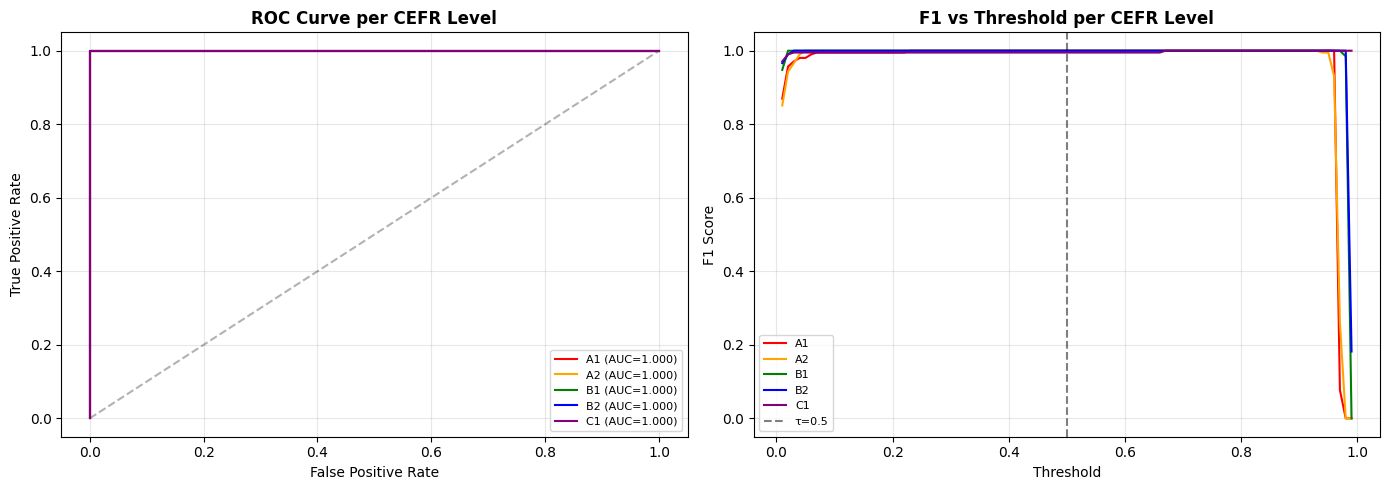

💾 Saved: baseline_roc_threshold.png

🔍 KEY INSIGHT:
  A1: optimal τ=0.23 (vs global τ=0.5) → justifies per-level calibration
  A2: optimal τ=0.05 (vs global τ=0.5) → justifies per-level calibration
  B1: optimal τ=0.02 (vs global τ=0.5) → justifies per-level calibration
  B2: optimal τ=0.03 (vs global τ=0.5) → justifies per-level calibration
  C1: optimal τ=0.67 (vs global τ=0.5) → justifies per-level calibration


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve per group
colors = {'A1':'red','A2':'orange','B1':'green','B2':'blue','C1':'purple'}
axes[0].plot([0,1],[0,1],'k--', alpha=0.3)
for lvl in ['A1','A2','B1','B2','C1']:
    if lvl not in tr['per_group']: continue
    mask = np.array([c == lvl for c in tr['cefrs']])
    if mask.sum() == 0: continue
    fpr, tpr, _ = roc_curve(tr['labels'][mask], tr['probs'][mask])
    axes[0].plot(fpr, tpr, color=colors[lvl], label=f'{lvl} (AUC={tr["per_group"][lvl]["auc"]:.3f})')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve per CEFR Level', fontweight='bold')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

# F1 vs Threshold per group
thresholds = np.linspace(0.01, 0.99, 99)
for lvl in ['A1','A2','B1','B2','C1']:
    if lvl not in tr['per_group']: continue
    mask = np.array([c == lvl for c in tr['cefrs']])
    if mask.sum() == 0: continue
    f1s = [f1_score(tr['labels'][mask], (tr['probs'][mask]>=t).astype(int)) for t in thresholds]
    axes[1].plot(thresholds, f1s, color=colors[lvl], label=lvl)
axes[1].axvline(x=0.5, color='black', linestyle='--', alpha=0.5, label='τ=0.5')
axes[1].set_xlabel('Threshold'); axes[1].set_ylabel('F1 Score')
axes[1].set_title('F1 vs Threshold per CEFR Level', fontweight='bold')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.savefig('baseline_roc_threshold.png', dpi=150); plt.show()
print('💾 Saved: baseline_roc_threshold.png')

# Key insight: single threshold 0.5 is NOT optimal for all levels
print(f'\n🔍 KEY INSIGHT:')
for lvl in ['A1','A2','B1','B2','C1']:
    if lvl not in tr['per_group']: continue
    mask = np.array([c == lvl for c in tr['cefrs']])
    f1s = [f1_score(tr['labels'][mask], (tr['probs'][mask]>=t).astype(int)) for t in thresholds]
    best_t = thresholds[np.argmax(f1s)]
    print(f'  {lvl}: optimal τ={best_t:.2f} (vs global τ=0.5) → justifies per-level calibration')

## 9. Experiment Log & Download

In [ ]:
log = {
    'experiment': 'B2.1 — Baseline Detector (Single Global Threshold)',
    'timestamp': datetime.now().isoformat(),
    'model': MODEL_NAME, 'device': str(DEVICE),
    'features': {'xlmr_dim': 768, 'ling_dim': LING_DIM, 'ling_features': feat_names},
    'train_size': len(train_data), 'val_size': len(val_data), 'test_size': len(test_data),
    'hyperparameters': {'epochs': EPOCHS, 'batch_size': BATCH_SIZE, 'lr': LR,
                        'warmup': WARMUP, 'wd': WEIGHT_DECAY, 'pos_weight': float(pos_weight)},
    'results': {
        'global_f1': float(tr['f1']), 'global_auc': float(tr['auc']), 'global_acc': float(tr['acc']),
        'per_group': {lvl: {k: float(v) if isinstance(v, (np.floating, np.integer)) else v
                            for k, v in g.items()}
                      for lvl, g in tr['per_group'].items()}
    },
    'calibration': 'single_global_threshold_0.5',
    'next': 'B2.2 — CEFR-Calibrated Detector'
}
with open('experiment_log_b2.1.json', 'w', encoding='utf-8') as f:
    json.dump(log, f, indent=2, ensure_ascii=False, default=str)

# Convert numpy.int64 types in 'preds' and 'labels' to standard Python int for JSON serialization
# Create a copy of tr to modify for serialization, as tr might be used elsewhere with original types
tr_serializable = {k: v for k, v in tr.items()}
# Recreate 'preds' from 'probs' using a threshold of 0.5, as it was missing from the `tr` dictionary
tr_serializable['preds'] = (tr_serializable['probs'] >= 0.5).astype(int)
tr_serializable['preds'] = [int(x) for x in tr_serializable['preds']]
tr_serializable['labels'] = [int(x) for x in tr_serializable['labels']]
tr_serializable['probs'] = tr_serializable['probs'].tolist() # Convert numpy array to list

with open('experiment_log_b2.1_detail.json', 'w', encoding='utf-8') as f1:
    json.dump(tr_serializable, f1, indent=2, ensure_ascii=False)

print('💾 Saved: experiment_log_b2.1.json')

💾 Saved: experiment_log_b2.1.json


In [ ]:
!zip -j b2.1_baseline_results.zip checkpoints/baseline_detector.pt experiment_log_b2.1.json baseline_roc_threshold.png
files.download('b2.1_baseline_results.zip')